# **E-Commerce Behavior: Predicting Online Shopper Purchasing Intention from Session Data.**

# **Importing Relevent Files & Loading Dataset**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('online_shoppers_intention.csv')

# **Exploratory Data Analysis**

## **Data Description**
Dataset inspection and checking missing values

In [2]:
# Basic inspection
print("Dataset Shape:", df.shape)
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (12330, 18)

Missing Values Count:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Data Types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems 

## **Descriptive Statistical Analysis**
This helps determine if the dataset is balanced or imbalanced.

In [3]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## **Target Variable Distribution**
This helps determine if the dataset is balanced or imbalanced.

/tmp/ipykernel_4227/2467911328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='viridis')


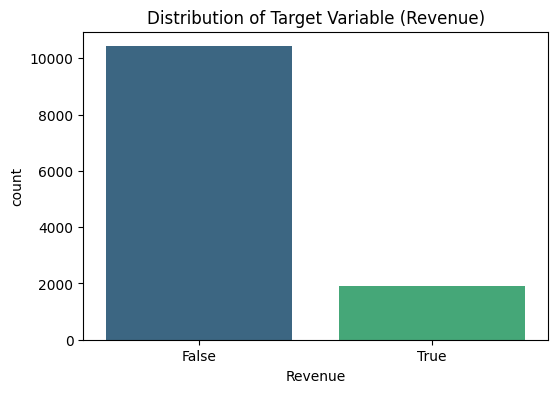

In [4]:
# Distribution of Target Variable (Revenue)
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Revenue)')
plt.show()

## **Distribution of Numerical Features**
Visualizing the spread of the continuous variables.

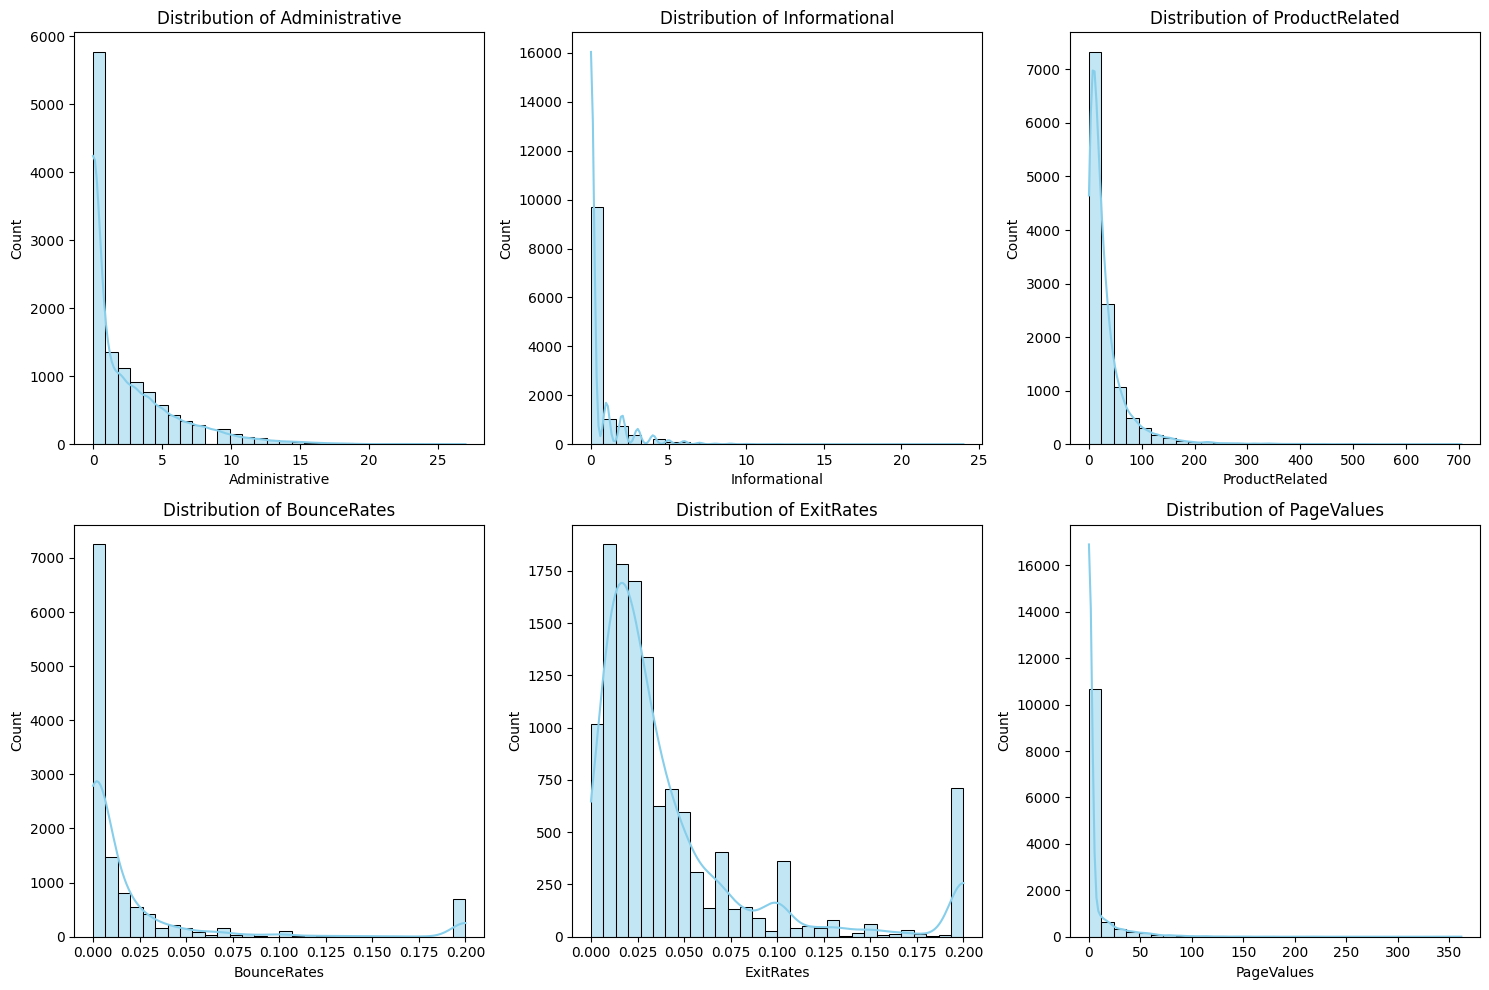

In [5]:
# Distribution of Key Numerical Features
numerical_features = ['Administrative', 'Informational', 'ProductRelated', 'BounceRates', 'ExitRates', 'PageValues']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## **Count Plots for Categorical Variables**
Analyzing the frequency of categorical attributes like visitor type and timing.

/tmp/ipykernel_4227/3865406089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma', order=order)
/tmp/ipykernel_4227/3865406089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma', order=order)
/tmp/ipykernel_4227/3865406089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma', order=order)
/tmp/ipykernel_4227/3865406089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

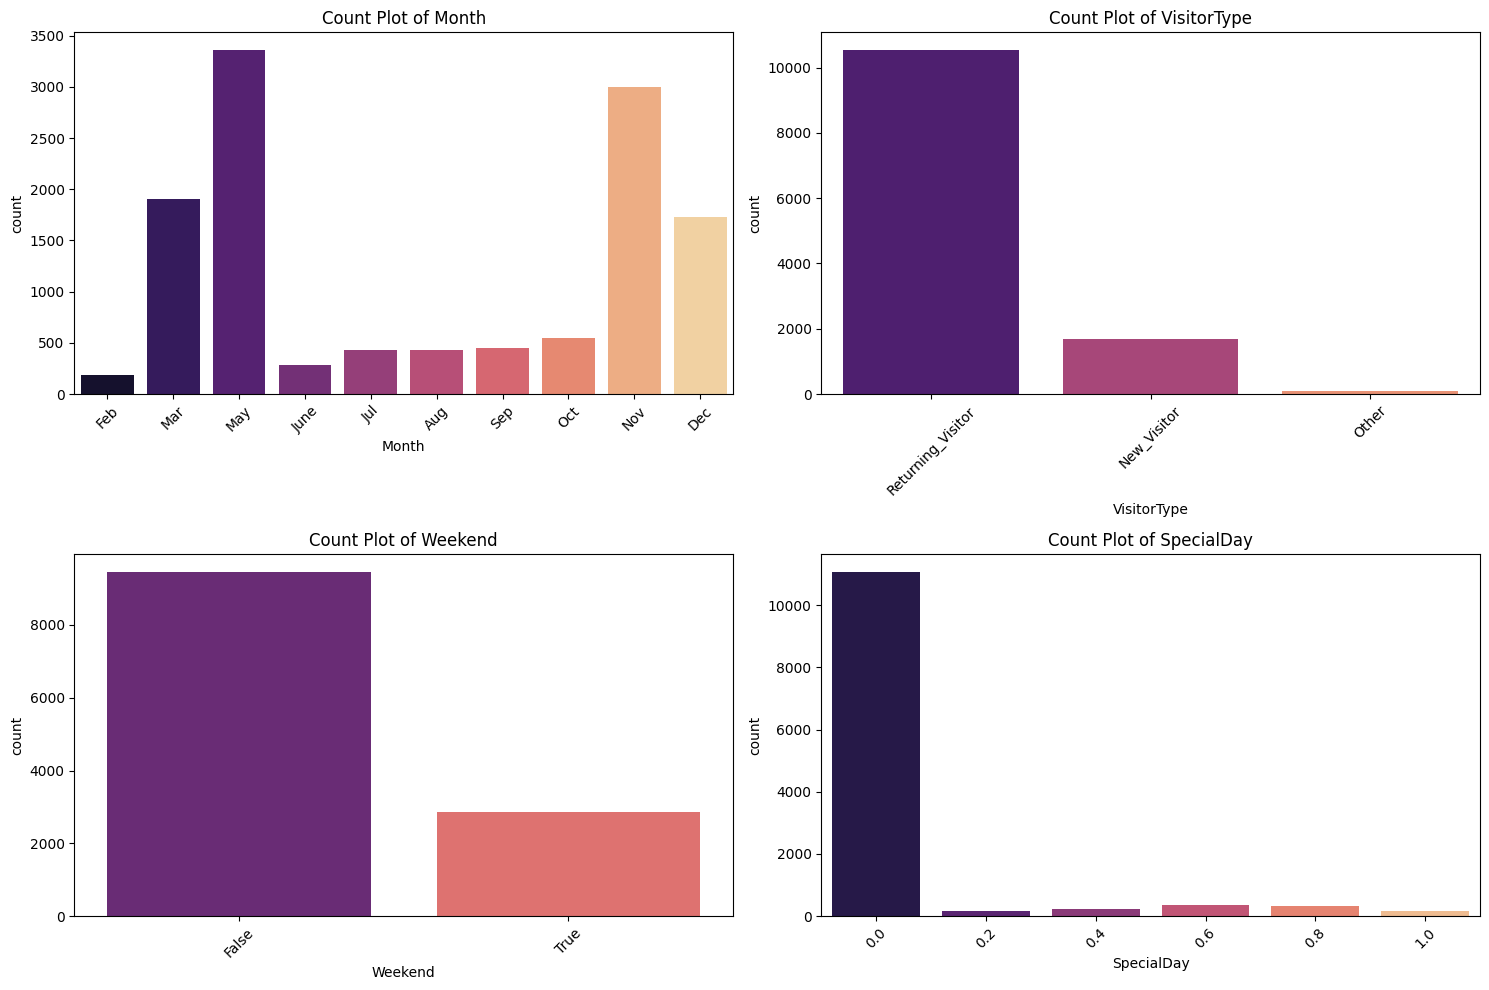

In [6]:
# Categorical Variables Count Plots
categorical_features = ['Month', 'VisitorType', 'Weekend', 'SpecialDay']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] if col == 'Month' else None
    sns.countplot(x=col, data=df, palette='magma', order=order)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Correlation Metrics**
A heatmap to identify relationships between numerical features and the target.

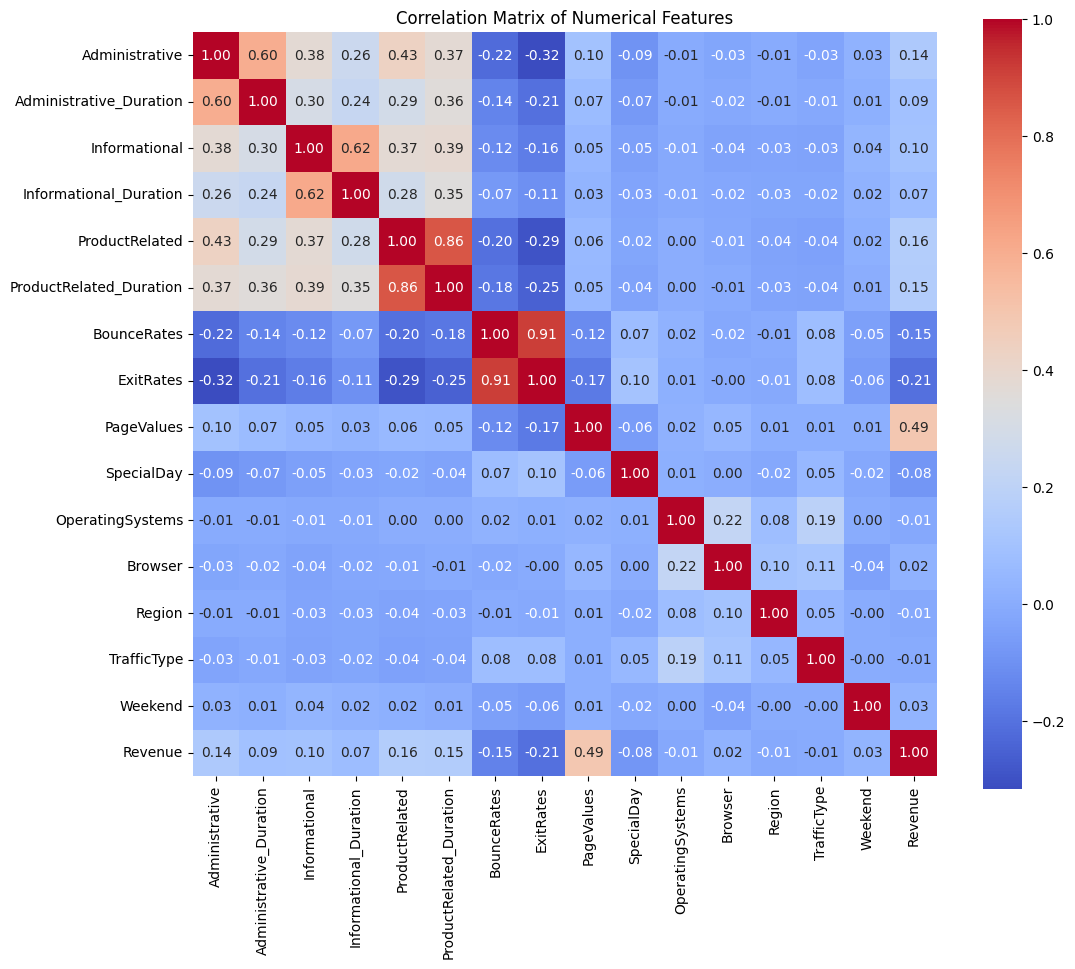

In [7]:
# Correlation Matrix Heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64', 'bool'])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# **Correlation between BounceRate and ExitRate**

Pearson Correlation Coefficient: 0.9130


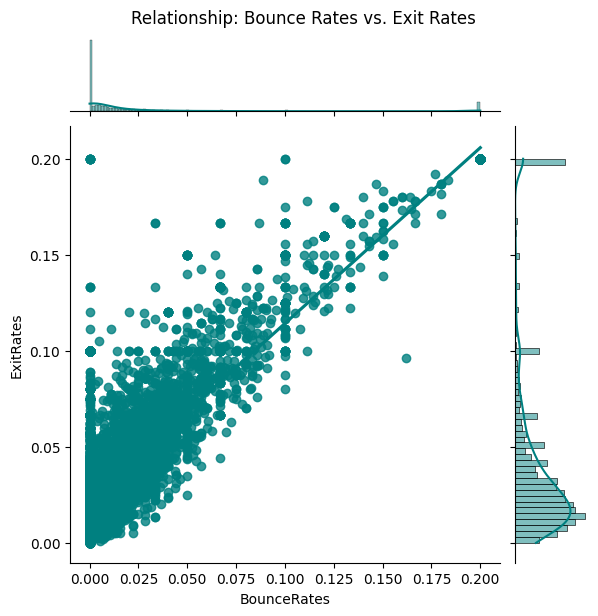

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Pearson correlation
correlation = df['BounceRates'].corr(df['ExitRates'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

# Visualize the relationship
sns.jointplot(x='BounceRates', y='ExitRates', data=df, kind='reg', color='teal')
plt.suptitle('Relationship: Bounce Rates vs. Exit Rates', y=1.02)
plt.savefig('correlation_analysis.png')

# **Model Training**

## **Preprocessing**

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle categorical variables (One-Hot Encoding)
df_final = pd.get_dummies(df, columns=['Month', 'OperatingSystems', 'Browser',
                                       'Region', 'TrafficType', 'VisitorType'], drop_first=True)

# Define Features and Target
X = df_final.drop('Revenue', axis=1)
y = df_final['Revenue']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Crucial for SVM and LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Model Training**

In [11]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian NB": GaussianNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

# Display results
eval_df = pd.DataFrame(results).T
print(eval_df)

                     Accuracy  Precision    Recall        F1
SVM                  0.882401   0.747312  0.363874  0.489437
Logistic Regression  0.881184   0.737968  0.361257  0.485062
Gaussian NB          0.253041   0.169683  0.981675  0.289352


## **Visualizations**

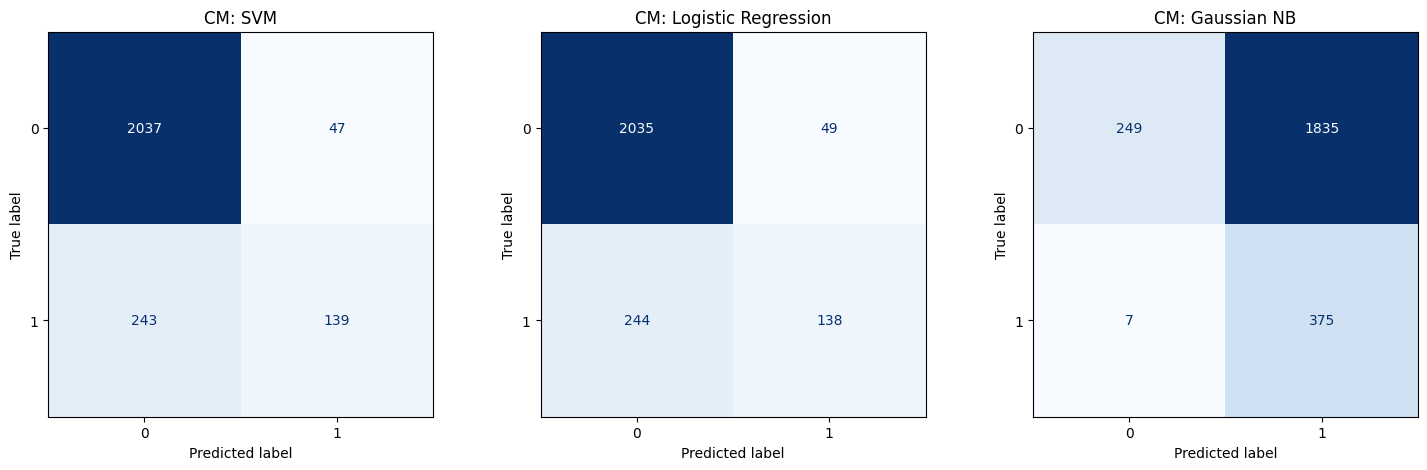

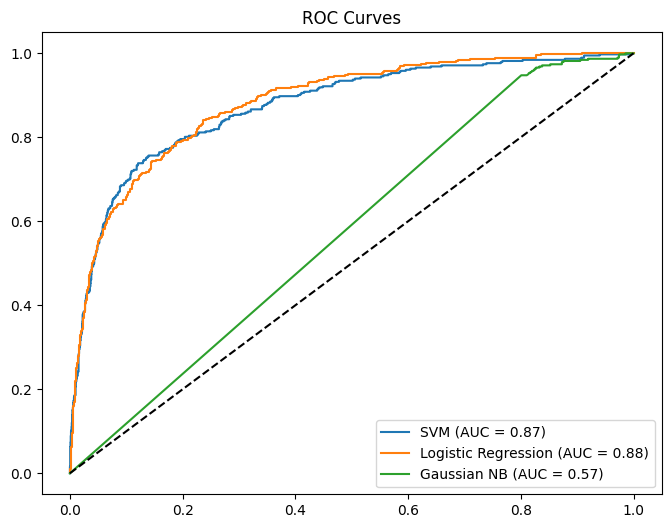

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"CM: {name}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_title("ROC Curves")
ax_roc.legend()
plt.show()

# **Hyperparameter Optimization**

In [13]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 1.3 MB/s eta 0:00:00


In [14]:
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def objective_svm(trial):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

    model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)
    return cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='f1').mean()

def objective_lr(trial):
    c = trial.suggest_float('C', 0.01, 10, log=True)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs'])

    model = LogisticRegression(C=c, solver=solver, max_iter=1000, random_state=42)
    return cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='f1').mean()

def objective_nb(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-1, log=True)

    model = GaussianNB(var_smoothing=var_smoothing)
    return cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=3, scoring='f1').mean()

In [15]:
# Create studies
studies = {
    "SVM": optuna.create_study(direction='maximize'),
    "Logistic Regression": optuna.create_study(direction='maximize'),
    "Gaussian NB": optuna.create_study(direction='maximize')
}

# Run optimization (n_trials=20 is usually enough for these models)
studies["SVM"].optimize(objective_svm, n_trials=20)
studies["Logistic Regression"].optimize(objective_lr, n_trials=20)
studies["Gaussian NB"].optimize(objective_nb, n_trials=20)

final_results = []

# Map of best models for later use
best_tuned_models = {
    "SVM": SVC(**studies["SVM"].best_params, probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(**studies["Logistic Regression"].best_params, random_state=42),
    "Gaussian NB": GaussianNB(**studies["Gaussian NB"].best_params)
}

for name, model in best_tuned_models.items():
    # Train the best version on the full training set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Store all 4 metrics
    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Best Params": studies[name].best_params
    })

# Display final comparison table
results_df = pd.DataFrame(final_results)
print("\n--- Final Optuna Optimized Results ---")
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']])

[I 2026-04-17 16:39:39,582] A new study created in memory with name: no-name-c9bae723-bf5a-4c75-b168-47912985d555
[I 2026-04-17 16:39:39,585] A new study created in memory with name: no-name-29bf13de-67be-4bdd-9164-728854f0f148
[I 2026-04-17 16:39:39,588] A new study created in memory with name: no-name-bee5cab5-78e8-4754-ad08-9816268b9d5d
[I 2026-04-17 16:39:54,730] Trial 0 finished with value: 0.3483319111300136 and parameters: {'C': 1.682044051849703, 'kernel': 'poly', 'gamma': 'auto'}. Best is trial 0 with value: 0.3483319111300136.
[I 2026-04-17 16:40:09,377] Trial 1 finished with value: 0.5605474519291632 and parameters: {'C': 5.302228740262432, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.5605474519291632.
[I 2026-04-17 16:40:22,637] Trial 2 finished with value: 0.5606523650459705 and parameters: {'C': 9.19276505205487, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 2 with value: 0.5606523650459705.
[I 2026-04-17 16:40:30,137] Trial 3 finished with value: 


--- Final Optuna Optimized Results ---
                 Model  Accuracy  Precision    Recall  F1-Score
0                  SVM  0.878751   0.660232  0.447644  0.533541
1  Logistic Regression  0.881184   0.737968  0.361257  0.485062
2          Gaussian NB  0.435118   0.202121  0.897906  0.329966


## **K-Fold Cross Validation**

In [16]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold to maintain class balance across folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_summary = []

print("--- Running 5-Fold Cross Validation ---")

for name, model in best_tuned_models.items():
    # Define multiple metrics to track during CV
    scoring = ['accuracy', 'precision', 'recall', 'f1']

    # Perform Cross Validation
    cv_scores = cross_validate(model, X_train_scaled, y_train,
                              cv=skf, scoring=scoring, n_jobs=-1)

    # Organize results into a summary dictionary
    cv_results_summary.append({
        "Model": name,
        "CV Accuracy": f"{cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std() * 2:.4f})",
        "CV Precision": f"{cv_scores['test_precision'].mean():.4f} (+/- {cv_scores['test_precision'].std() * 2:.4f})",
        "CV Recall": f"{cv_scores['test_recall'].mean():.4f} (+/- {cv_scores['test_recall'].std() * 2:.4f})",
        "CV F1-Score": f"{cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std() * 2:.4f})"
    })

# Convert to DataFrame for a clean final report
cv_report_df = pd.DataFrame(cv_results_summary)
print(cv_report_df.to_string(index=False))

--- Running 5-Fold Cross Validation ---
              Model         CV Accuracy        CV Precision           CV Recall         CV F1-Score
                SVM 0.8877 (+/- 0.0101) 0.7098 (+/- 0.0725) 0.4672 (+/- 0.0520) 0.5625 (+/- 0.0376)
Logistic Regression 0.8845 (+/- 0.0086) 0.7405 (+/- 0.0462) 0.3906 (+/- 0.0537) 0.5109 (+/- 0.0514)
        Gaussian NB 0.4620 (+/- 0.0926) 0.2120 (+/- 0.0232) 0.9050 (+/- 0.0637) 0.3431 (+/- 0.0263)


# **How Temporal Features Affect?**

## **Feature Engineering: Holiday vs. Non-Holiday**

In [17]:
# Create a copy for analysis
df_temp = df.copy()

# Define Holiday months (Nov and Dec are usually peak in this dataset)
df_temp['Is_Holiday_Period'] = df_temp['Month'].apply(lambda x: 1 if x in ['Nov', 'Dec'] else 0)

# Create two versions of the dataset:
# 1. With Temporal Features
# 2. Without Temporal Features
temporal_cols = ['Month', 'Weekend', 'SpecialDay']

# Encode the full set for the "With" version
df_with = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Remove temporal features for the "Without" version
df_without = df_with.drop(columns=[col for col in df_with.columns if any(t in col for t in temporal_cols)], errors='ignore')

## **Comparative Model Training**

In [18]:
from sklearn.metrics import f1_score

def evaluate_impact(X_data, y_data, model):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    # Re-scale as features changed
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds)

# Test both scenarios
f1_with = evaluate_impact(df_with.drop('Revenue', axis=1), df_with['Revenue'], best_tuned_models["SVM"])
f1_without = evaluate_impact(df_without.drop('Revenue', axis=1), df_without['Revenue'], best_tuned_models["SVM"])

print(f"F1-Score with Temporal Features: {f1_with:.4f}")
print(f"F1-Score without Temporal Features: {f1_without:.4f}")
print(f"Impact on Predictive Power: {((f1_with - f1_without) / f1_without) * 100:.2f}% improvement")

F1-Score with Temporal Features: 0.5760
F1-Score without Temporal Features: 0.5688
Impact on Predictive Power: 1.26% improvement


# **Model Explainability**

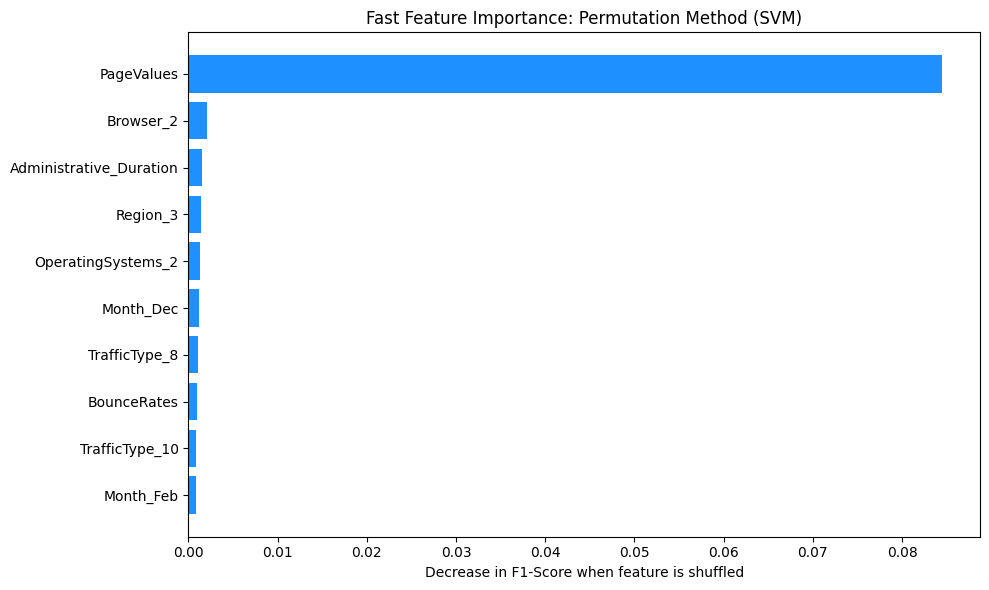

In [19]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Re-initialize and re-train the SVM model for permutation importance
# This is necessary because the `best_tuned_models["SVM"]` object was re-trained
# on different feature sets in the "How Temporal Features Affect?" section.

# Get the best parameters for SVM from the Optuna study
svm_best_params = studies["SVM"].best_params

# Create a new SVM model instance with the best parameters
svm_for_permutation = SVC(**svm_best_params, probability=True, random_state=42)

# Train this SVM model on the original X_train_scaled and y_train
# X_train_scaled and y_train come from the initial preprocessing (df_final)
svm_for_permutation.fit(X_train_scaled, y_train)

# Run permutation importance on the test set using the re-trained SVM
# n_repeats=5 is usually enough to get a stable estimate
result = permutation_importance(svm_for_permutation, X_test_scaled, y_test,
                                n_repeats=5, random_state=42, n_jobs=-1)

# Organize into a DataFrame
sorted_idx = result.importances_mean.argsort()
perm_table = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': result.importances_mean[sorted_idx]
})

# Plot Top 10
plt.figure(figsize=(10, 6))
plt.barh(perm_table['Feature'].tail(10), perm_table['Importance'].tail(10), color='dodgerblue')
plt.title("Fast Feature Importance: Permutation Method (SVM)")
plt.xlabel("Decrease in F1-Score when feature is shuffled")
plt.tight_layout()
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

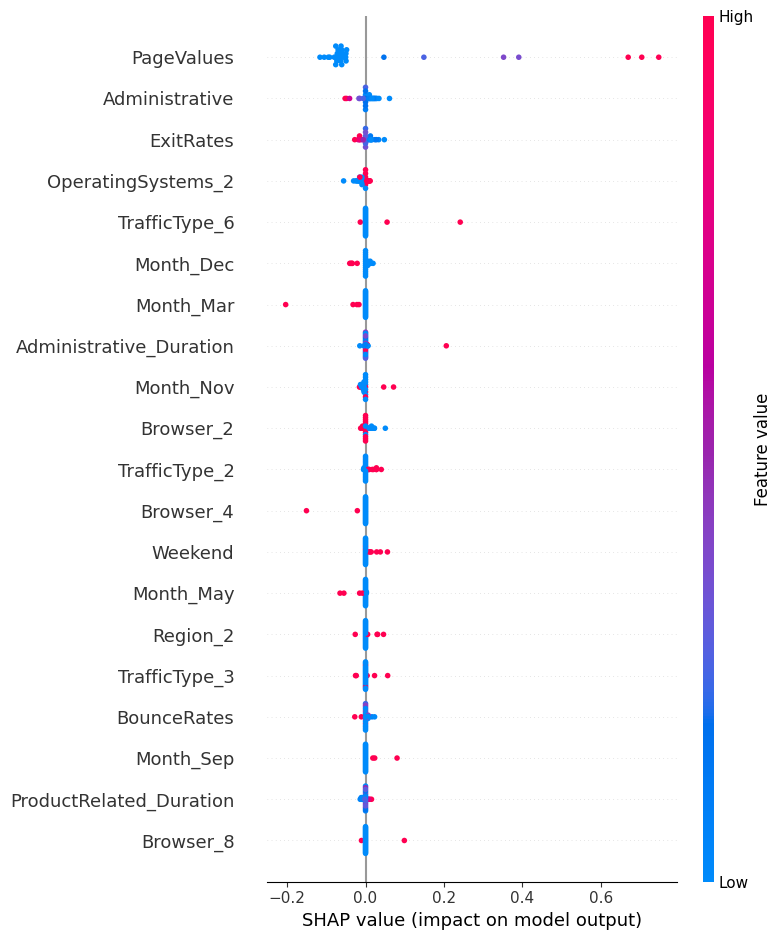

In [20]:
import shap

# 1. Summarize background data (10 points max for speed)
X_train_summary = shap.kmeans(X_train_scaled, 10)

# 2. Use KernelExplainer on the SVM probability function
# Note: SVM must have been trained with probability=True
# Use the svm_for_permutation model, which was correctly trained on X_train_scaled
explainer = shap.KernelExplainer(svm_for_permutation.predict_proba, X_train_summary)

# 3. Explain a small subset (e.g., 30 samples)
# This will take roughly 1-2 minutes
shap_values = explainer.shap_values(X_test_scaled[:30])

# 4. Summary Plot
# shap_values[:, :, 1] is the impact on "Revenue = True" for all samples
# The KernelExplainer for predict_proba returns shap_values as (n_samples, n_features, n_classes)
shap.summary_plot(shap_values[:, :, 1], X_test_scaled[:30], feature_names=X.columns)